# Trim single-cell reads

This notebook profile the thresholds for trimming read procedure.

Take 6 runs of K562, for example.

In [6]:
import glob, os
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
info = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv", index_col=0)
runs = [
    "20220719_K562_1", 
    "20220719_K562_2", 
    "20220719_K562_3", 
    "20220719_K562_4", 
    "20220729_K562_1", 
    "20220729_K562_2",
]

## 1. Profiling of dual-TSO (heatmap)

In [7]:
def stat_dual_tso_edit_distance(infiles, outfile):
    if os.path.exists(outfile):
        print("%s exists!" % outfile)
        return None
    counter = defaultdict(int)
    for infile in infiles:
        d = pd.read_csv(infile, sep="\t")
        for ed1, ed2, count in d[["ED1", "ED2", "Number"]].values:
            counter[(ed1, ed2)] += count
    m = pd.DataFrame([ed1, ed2, count] for (ed1, ed2), count in sorted(counter.items()))
    m.columns = ["ED1", "ED2", "Count"]
    m.to_csv(outfile, index=False)

for run in runs:
    tmp = info[info["Run"] == run]
    infiles = ["../../../1_NanoNASCseq/results/2_demux/4_trimmed/%s/%s/tso.tsv" % (run, cell) for cell in tmp.index]
    outfile = "results/dual_tso_edit_distance/%s.csv" % run
    stat_dual_tso_edit_distance(infiles, outfile)

In [11]:
for run in runs:
    m = np.zeros((6, 6), dtype=int)
    d = pd.read_csv("results/dual_tso_edit_distance/%s.csv" % run)
    for ed1, ed2, count in d.values:
        m[int(min(int(ed1), 11)/2)][int(min(int(ed2), 11)/2)] += int(count)
    m = pd.DataFrame(m)
    m = m * 100 / m.sum().sum()
    m.columns = ["0-1", "2-3", "4-5", "6-7", "8-9", "≥10"]
    m.index = ["0-1", "2-3", "4-5", "6-7", "8-9", "≥10"]
    array.append(m)
m = sum(array) / len(array)
m.to_csv("results/dual_tso_edit_distance.stats.csv")
m

,0-1,2-3,4-5,6-7,8-9,≥10
0-1,52.524303,7.449179,6.919949,4.167193,1.092860,0.327507
2-3,7.821935,1.357449,1.196703,0.691300,0.238762,0.082385
4-5,6.496686,0.989338,0.848624,0.459305,0.170439,0.060051
6-7,3.980781,0.564828,0.458109,0.253720,0.094495,0.033717
8-9,0.918235,0.163121,0.141305,0.079395,0.032450,0.011543
≥10,0.239326,0.049615,0.044706,0.025595,0.010479,0.004610


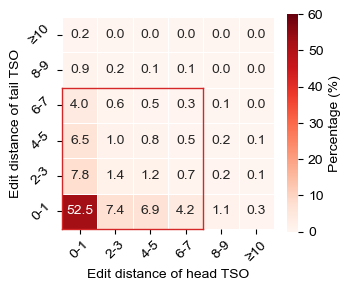

In [16]:
m = pd.read_csv("results/dual_tso_edit_distance.stats.csv", index_col=0)[::-1]
plt.figure(figsize=(3.6, 3))
sns.heatmap(m, annot=True, fmt=".1f", cmap="Reds", lw=0.5, vmin=0, vmax=60,
            square=True, cbar_kws={"label": "Percentage (%)"})
if True:
    plt.plot([0, 4], [2, 2], color="C3", lw=1, clip_on=False)
    plt.plot([0, 4], [6, 6], color="C3", lw=1, clip_on=False)
    plt.plot([0, 0], [2, 6], color="C3", lw=1, clip_on=False)
    plt.plot([4, 4], [2, 6], color="C3", lw=1, clip_on=False)
plt.xlabel("Edit distance of head TSO")
plt.ylabel("Edit distance of tail TSO")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/dual_tso_edit_distance.heatmap.pdf")
plt.show()
plt.close()

## 2. Profiling of polyA (heatmap)

In [19]:
def stat_dual_polya_length(infiles, outfile):
    if os.path.exists(outfile):
        print("%s exists!" % outfile)
        return None
    counter = defaultdict(int)
    for infile in infiles:
        d = pd.read_csv(infile, sep="\t")
        for a, t, count in d[["PolyA", "PolyT", "Number"]].values:
            counter[(a, t)] += count
    m = pd.DataFrame([[a, t, n] for (a, t), n in sorted(counter.items())])
    m.columns = ["PolyA", "PolyT", "Count"]
    m.to_csv(outfile, index=False)

for run in runs:
    tmp = info[info["Run"] == run]
    infiles = ["../../../1_NanoNASCseq/results/2_demux/4_trimmed/%s/%s/polya.tsv" % (run, cell) for cell in tmp.index]
    outfile = "results/dual_polya_length/%s.csv" % run
    stat_dual_polya_length(infiles, outfile)

results/dual_polya_length/20220719_K562_1.csv exists!
results/dual_polya_length/20220719_K562_2.csv exists!
results/dual_polya_length/20220719_K562_3.csv exists!
results/dual_polya_length/20220719_K562_4.csv exists!
results/dual_polya_length/20220729_K562_1.csv exists!
results/dual_polya_length/20220729_K562_2.csv exists!


In [22]:
array = []
for run in runs:
    m = np.zeros((6, 6), dtype=int)
    d = pd.read_csv("results/dual_polya_length/%s.csv" % run)
    for n1, n2, count in d.values:
        m[int(min(n1, 25)/5)][int(min(n2, 25)/5)] += int(count)
    m = pd.DataFrame(m)
    m = m * 100 / m.sum().sum()
    m.columns = ["0-4", "5-9", "10-14", "15-19", "20-24", "≥25"]
    m.index = m.columns
    array.append(m)
m = sum(array) / len(array)
m.to_csv("results/dual_polya_length.stats.csv")
m

,0-4,5-9,10-14,15-19,20-24,≥25
0-4,8.414722,1.211998,1.046537,2.894284,12.131968,23.546979
5-9,1.712660,0.157760,0.078208,0.207181,0.858757,1.547547
10-14,1.173741,0.076306,0.016270,0.031564,0.117905,0.193840
15-19,2.919387,0.197436,0.028543,0.038391,0.131099,0.218479
20-24,11.490573,0.775182,0.096604,0.098191,0.388206,0.679935
≥25,24.032650,1.494280,0.170181,0.149999,0.590185,1.082451


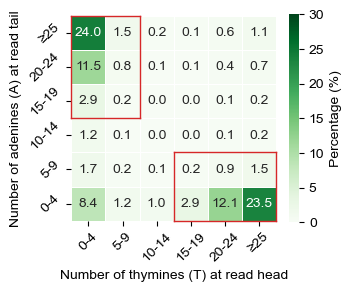

In [25]:
m = pd.read_csv("results/dual_polya_length.stats.csv", index_col=0)[::-1]
plt.figure(figsize=(3.6, 3))
sns.heatmap(m, annot=True, fmt=".1f", cmap="Greens", lw=0.5, vmin=0, vmax=30,
            square=True, cbar_kws={"label": "Percentage (%)"})
if True:
    plt.plot([0, 2], [0, 0], color="C3", lw=1, clip_on=False)
    plt.plot([0, 2], [3, 3], color="C3", lw=1, clip_on=False)
    plt.plot([0, 0], [0, 3], color="C3", lw=1, clip_on=False)
    plt.plot([2, 2], [0, 3], color="C3", lw=1, clip_on=False)
    
    plt.plot([3, 6], [4, 4], color="C3", lw=1, clip_on=False)
    plt.plot([3, 6], [6, 6], color="C3", lw=1, clip_on=False)
    plt.plot([3, 3], [4, 6], color="C3", lw=1, clip_on=False)
    plt.plot([6, 6], [4, 6], color="C3", lw=1, clip_on=False)
    
plt.xlabel("Number of thymines (T) at read head")
plt.ylabel("Number of adenines (A) at read tail")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/dual_polya_length.heatmap.pdf")
plt.show()
plt.close()

## 3. PolyA length (barplot)

In [27]:
def stat_polya_length(infiles, outfile):
    if os.path.exists(outfile):
        print("%s exists!" % outfile)
        return None

    counter = defaultdict(int)
    for infile in infiles:
        d = pd.read_csv(infile, sep="\t")
        for n1, n2, count in d[["PolyA", "PolyT", "Number"]].values:
            n = max(n1, n2)
            counter[n] += count
    m = pd.DataFrame(list(sorted(counter.items())))
    m.columns = ["Length", "Count"]
    m.to_csv(outfile, index=False)

for run in runs:
    tmp = info[info["Run"] == run]
    infiles = ["../../../1_NanoNASCseq/results/2_demux/4_trimmed/%s/%s/polya.tsv" % (run, cell) for cell in tmp.index]
    outfile = "results/polya_length/%s.csv" % run
    stat_polya_length(infiles, outfile)

In [37]:
max_len = 40
array = []
for run in runs:
    counts = np.zeros(max_len + 1)
    d = pd.read_csv("results/polya_length/%s.csv" % run)
    for length, count in d.values:
        counts[min(length, len(counts)-1)] += int(count)
    array.append(counts)
m = pd.DataFrame(array)
m = m.divide(m.sum(axis=1), axis=0) * 100
m.to_csv("results/polya_length.stats.csv")
m

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,0.000000,0.208038,3.216963,4.994309,2.267218,0.866042,0.485301,0.402577,0.554744,0.373927,...,2.245944,2.003410,1.865755,1.767642,1.648542,1.527493,1.497403,1.422992,1.467196,8.217340
1,0.000026,0.130936,2.130996,3.174193,1.800525,1.051472,0.890912,0.905236,0.852997,1.170072,...,1.654268,1.484790,1.368758,1.305265,1.264313,1.233196,1.289200,1.327537,1.595458,11.360533
2,0.000014,0.110820,1.459461,2.614983,1.553771,0.732255,0.651126,0.445548,0.473291,0.539273,...,2.395854,2.088868,1.846982,1.660361,1.470744,1.312433,1.256779,1.184403,1.231835,7.687512
3,0.000000,0.231173,3.676759,5.540477,2.234677,0.906771,0.678471,0.483421,0.599889,0.538604,...,2.418222,2.179573,1.985136,1.833099,1.649500,1.476974,1.393810,1.299610,1.316875,7.811601
4,0.000003,0.156641,2.682483,4.487762,1.998106,1.021822,0.722979,0.685121,0.670459,0.871898,...,2.001188,1.774309,1.622426,1.506360,1.392052,1.303633,1.297227,1.275214,1.409803,8.706193
5,0.000004,0.120113,1.783261,2.984593,0.930025,0.305157,0.234321,0.110585,0.172607,0.097631,...,2.275414,2.121724,2.080071,2.104955,2.091720,2.072825,2.105552,2.092321,2.265641,13.503231


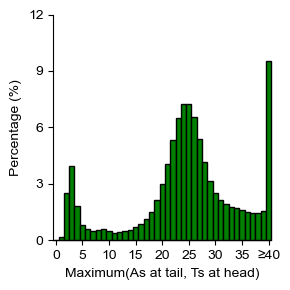

In [38]:
m = pd.read_csv("results/polya_length.stats.csv", index_col=0)
ys = m.mean(axis=0)
yerr = m.std(axis=0)
xs = np.arange(len(ys))

plt.figure(figsize=(3, 3))
plt.bar(xs, ys, yerr=yerr, color="green", edgecolor="black", 
        lw=1, width=1, error_kw={"capsize": 0, "lw": 0}, clip_on=False)
plt.xlim(min(xs) - 0.5, max(xs) + 0.5)
plt.xticks([0, 5, 10, 15, 20, 25, 30, 35, 40], ["0", "5", "10", "15", "20", "25", "30", "35", "≥40"])
plt.ylim(0, 12)
plt.yticks(np.arange(0, 13, 3))
# plt.text(2, 15 * 0.9, "MAX(As, Ts) ≥ 15 (%.1f%%)" % sum(ys[15:]))
plt.xlabel("Maximum(As at tail, Ts at head)")
plt.ylabel("Percentage (%)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/polya_length.bar.pdf")
plt.show()
plt.close()

## 4. Edit distance of anchor (barplot)

In [42]:
max_ed = 5
rows = []
for run in runs:
    counter = defaultdict(int)
    for cell in info[info["Run"] == run].index:
        path = "../../../1_NanoNASCseq/results/2_demux/4_trimmed/%s/%s/anchor.tsv" % (run, cell)
        with open(path) as f:
            for i, line in enumerate(f):
                if i > 0:
                    row = line.strip("\n").split("\t")
                    x, ed, count = row[:3]
                    if int(x) <= 2:
                        counter[int(ed)] += int(count)
    row = [counter[ed] for ed in range(0, max_ed)]
    row.append(sum(counter.values()) - sum(row))
    rows.append(row)
d = pd.DataFrame(rows)
d = d.divide(d.sum(axis=1), axis=0) * 100
d

,0,1,2,3,4,5
0,90.589814,6.418828,1.631450,1.122721,0.218222,0.018965
1,88.613153,7.392766,2.113700,1.619662,0.250595,0.010125
2,90.073368,6.557453,1.749297,1.358396,0.245148,0.016338
3,90.800209,6.237026,1.534020,1.217107,0.202519,0.009119
4,89.684976,6.855339,1.879477,1.318256,0.246685,0.015267
5,91.129362,6.237546,1.543471,0.920121,0.151568,0.017932


In [43]:
vs = d[[0, 1, 2]].sum(axis=1)
mean, std = np.mean(vs), np.std(vs)
print(mean, std)

98.50687599019146 0.24437863741509544


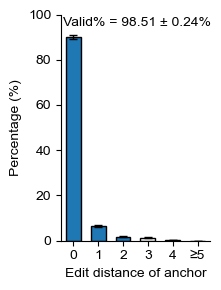

In [45]:
ys = d.mean(axis=0)
yerr = d.std(axis=0)
xs = np.arange(len(ys))
ticks = [str(ed) for ed in range(max_ed + 1)]
ticks[-1] = "≥%s" % ticks[-1]
colors = ["C0", "C0", "C0", "none", "none", "none"]

plt.figure(figsize=(2.3, 3))
plt.bar(xs, ys, yerr=yerr, width=0.6, color=colors, edgecolor="black", error_kw={"capsize": 3, "lw": 1})
plt.text(-0.4, 100 * 0.95, "Valid%% = %.2f ± %.2f%%" % (mean, std))
plt.xlim(-0.5, 5.5)
plt.ylim(0, 100)
plt.xticks(xs, ticks)
plt.xlabel("Edit distance of anchor")
plt.ylabel("Percentage (%)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/anchor_edit_distance.bar.pdf")
plt.show()
plt.close()

## 5. Profiling of UMI length (barplot)

In [46]:
rows = []
min_len = 8
max_len = 16
for run in runs:
    counts = np.zeros(max_len - min_len + 1)
    for path in sorted(glob.glob("../../../1_NanoNASCseq/results/2_demux/4_trimmed/%s/*/umi.tsv" % run)):
        with open(path) as f:
            for i, line in enumerate(f):
                if i > 0:
                    row = line.strip("\n").split("\t")
                    v = int(row[0])
                    count = int(row[1])
                    v = max(v, min_len)
                    v = min(v, max_len)
                    counts[v - min_len] += count
    rows.append(counts)
m = pd.DataFrame(rows, index=runs)
m = m.divide(m.sum(axis=1), axis=0) * 100
m

,0,1,2,3,4,5,6,7,8
20220719_K562_1,3.005198,1.145481,1.790846,3.861215,82.460763,4.215236,1.668681,0.781468,1.071112
20220719_K562_2,3.109400,1.335220,2.356582,5.474409,78.433722,5.187040,1.988304,0.938154,1.177169
20220719_K562_3,3.059493,1.223948,1.968959,4.622864,80.870453,4.482399,1.797903,0.843966,1.130016
20220719_K562_4,1.756129,0.961186,1.671481,3.977094,83.913205,4.150696,1.702441,0.794130,1.073638
20220729_K562_1,3.964888,1.301676,2.045284,4.331037,80.537346,4.420494,1.640503,0.767338,0.991434
20220729_K562_2,3.392091,1.007819,1.650402,3.583083,82.758699,3.994095,1.630684,0.806904,1.176223


In [47]:
vs = m[[3, 4, 5]].sum(axis=1)
mean, std = np.mean(vs), np.std(vs)
print(mean, std)

90.21230788224936 0.9679553244347806


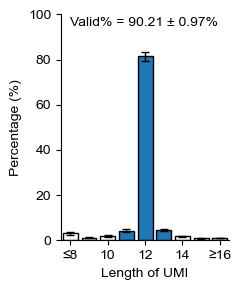

In [48]:
ys = m.mean(axis=0)
yerr = m.std(axis=0)
xs = np.arange(len(ys)) + min_len
colors = ["none", "none", "none", "C0", "C0", "C0", "none", "none", "none"]
plt.figure(figsize=(2.5, 3))
plt.bar(xs, ys, yerr=yerr, color=colors, width=0.8, edgecolor="black", error_kw={"capsize": 3, "lw": 1})
plt.text(8, 100 * 0.95, "Valid%% = %.2f ± %.2f%%" % (mean, std))
plt.xlim(min(xs) - 0.5, max(xs) + 0.5)
plt.ylim(0, 100)
xs1 = np.arange(min_len, max_len + 1, 2)
ticks = [str(x) for x in xs1]
ticks[0] = "≤%s" % ticks[0]
ticks[-1] = "≥%s" % ticks[-1]
plt.xticks(xs1, ticks)
plt.xlabel("Length of UMI")
plt.ylabel("Percentage (%)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/umi_length.bar.pdf")
plt.show()
plt.close()

## 6. Summary of trimming (barplot)

In [55]:
array = []
for run in runs:
    for cell in info[info["Run"] == run].index:
        path = "../../../1_NanoNASCseq/results/2_demux/4_trimmed/%s/%s/stats.tsv" % (run, cell)
        d = pd.read_csv(path, sep="\t", index_col=0)
        array.append(d)
d = pd.concat(array)
d["TooShort"] = d["RawTooShort"] + d["TrimTooShort"]

In [58]:
cs = ["Total", "NoTSO", "IsChimeric", "NoDirection", "NoAnchor", "NoUMI", "TooShort", "Pass"]
array = []
for c in cs:
    s = d[c] / d["Total"]
    s.name = c
    array.append(s)
m = pd.concat(array, axis=1)
m.to_csv("results/strict_trim_porportion.stats.csv")
m

,Total,NoTSO,IsChimeric,NoDirection,NoAnchor,NoUMI,TooShort,Pass
File,,,,,,,,
20220719_K562_1.C01.K562_s4U_50uM_15min.fastq.gz,1.0,0.020266,0.008734,0.174975,0.017649,0.068624,0.000057,0.709695
20220719_K562_1.C02.K562_s4U_50uM_15min.fastq.gz,1.0,0.015643,0.014634,0.224399,0.014845,0.059056,0.000000,0.671423
20220719_K562_1.C03.K562_s4U_50uM_15min.fastq.gz,1.0,0.013581,0.009526,0.190367,0.019914,0.076960,0.000574,0.689077
20220719_K562_1.C04.K562_s4U_50uM_15min.fastq.gz,1.0,0.020936,0.009223,0.175368,0.022780,0.081999,0.000282,0.689413
20220719_K562_1.C05.K562_s4U_50uM_15min.fastq.gz,1.0,0.014694,0.007599,0.119679,0.016071,0.077443,0.000188,0.764327
...,...,...,...,...,...,...,...,...
20220729_K562_2.C74.K562_s4U_50uM_180min.fastq.gz,1.0,0.009973,0.012502,0.060445,0.016599,0.085223,0.000084,0.815175
20220729_K562_2.C75.K562_s4U_50uM_180min.fastq.gz,1.0,0.014611,0.016022,0.087215,0.017126,0.074198,0.000070,0.790758
20220729_K562_2.C76.K562_s4U_50uM_180min.fastq.gz,1.0,0.022100,0.009196,0.066803,0.023209,0.114608,0.000192,0.763892


In [68]:
m = pd.read_csv("results/strict_trim_porportion.stats.csv", index_col=0)
d = pd.DataFrame(dict(Mean=m.mean(axis=0), Std=m.std(axis=0), Size=len(m)))
d

,Mean,Std,Size
Total,1.000000,0.000000,438
NoTSO,0.019005,0.005809,438
IsChimeric,0.013424,0.004369,438
NoDirection,0.176434,0.058375,438
NoAnchor,0.019446,0.004222,438
NoUMI,0.076122,0.015048,438
TooShort,0.000158,0.000273,438
Pass,0.695412,0.056228,438


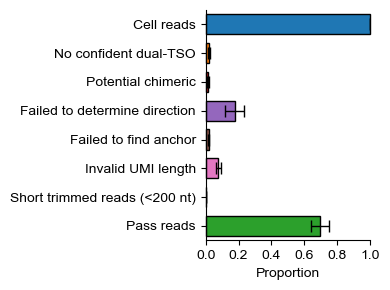

In [67]:
ticks = ["Cell reads", 
         "No confident dual-TSO", 
         "Potential chimeric", 
         "Failed to determine direction", 
         "Failed to find anchor", 
         "Invalid UMI length",
         "Short trimmed reads (<200 nt)",
         "Pass reads"]
colors = ["C0", "C1", "C3", "C4", "C5", "C6", "C7", "C2"]
xs = np.arange(len(d))[::-1]

plt.figure(figsize=(4, 3))
plt.barh(xs, d["Mean"], xerr=d["Std"], edgecolor="black", height=0.7, clip_on=False,
         error_kw={"capsize": 4, "lw": 1}, color=colors)
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.yticks(xs, ticks, rotation=0)
plt.ylim(min(xs) - 0.5, max(xs) + 0.5)
plt.xlim(0, 1)
plt.xlabel("Proportion")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/strict_trim_porportion.bar.pdf")
plt.show()
plt.close()

## 7. Summary of cell reads (barplot)

20220719_K562_1


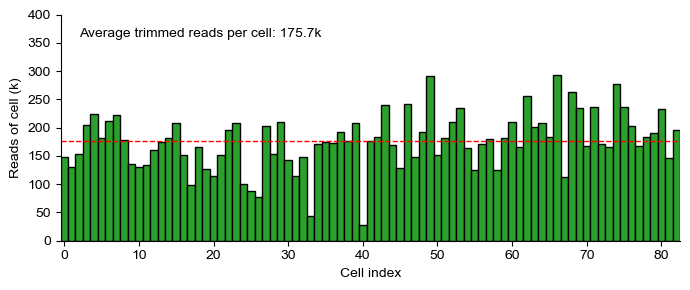

20220719_K562_2


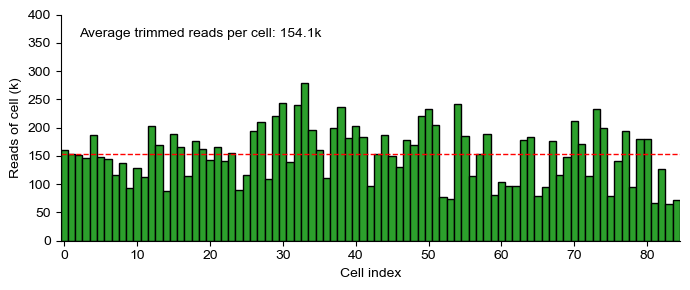

20220719_K562_3


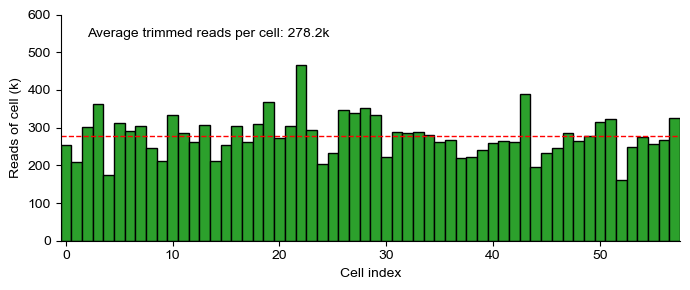

20220719_K562_4


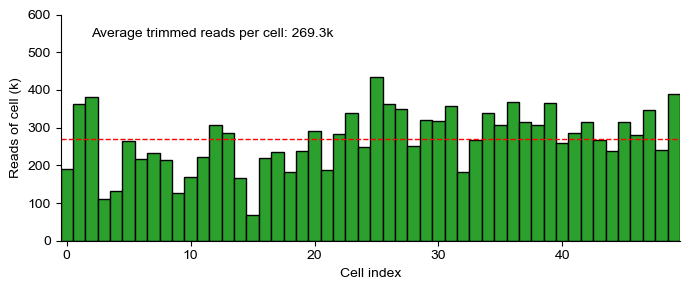

20220729_K562_1


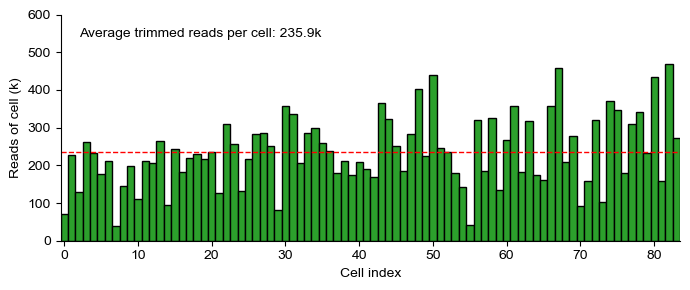

20220729_K562_2


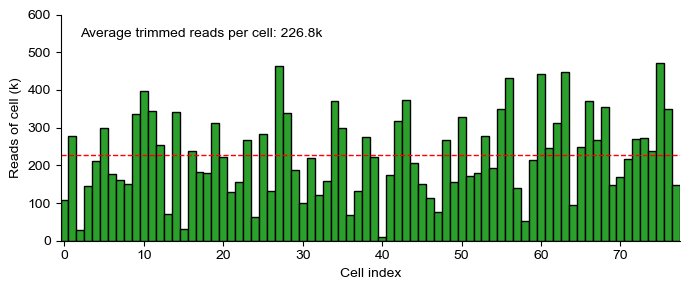

In [22]:
for run in runs:
    print(run)
    # if run != "20220719_K562_1":
    #     continue
    ys = []
    for cell in info[info["Run"] == run]["Cell"]:
        p = "../../../1_NanoNASCseq/results/2_demux/4_trimmed/%s/%s/stats.tsv" % (run, cell)
        d = pd.read_csv(p, sep="\t", index_col=0)
        y = d["Pass"].values[0]
        ys.append(y)
    ys = np.array(ys) / 1e3
    xs = np.arange(len(ys))
    plt.figure(figsize=(7, 3))
    plt.bar(xs, ys, width=1, color="C2", edgecolor="black", lw=1)
    plt.axhline(np.mean(ys), lw=1, ls="--", color="red")
    ylim = (int(max(ys) / 100) + 2) * 100
    plt.text(2, ylim * 0.9, "Average trimmed reads per cell: %.1fk" % np.mean(ys))
    plt.xlim(min(xs) - 0.5, max(xs) + 0.5)
    plt.ylim(0, ylim)
    plt.xlabel("Cell index")
    plt.ylabel("Reads of cell (k)")
    for loc in ["top", "right"]:
        plt.gca().spines[loc].set_visible(False)
    plt.tight_layout()
    plt.savefig("figures/average_reads_per_cell.pdf")
    plt.show()
    plt.close()

In [4]:
data1 = []
data2 = []
for run in runs:
    ys = []
    for cell in info[info["Run"] == run]["Cell"]:
        p = "../../../1_NanoNASCseq/results/2_demux/4_trimmed/%s/%s/stats.tsv" % (run, cell)
        d = pd.read_csv(p, sep="\t", index_col=0)
        y = d["Pass"].values[0]
        ys.append(y)
    ys = np.array(ys) / 1e3
    data1.append(ys)
    data2.extend(ys)

Cells	Median	Mean
83	175.98	175.75
85	153.66	154.1
58	273.28	278.2
50	274.25	269.32
84	229.14	235.87
78	218.33	226.84


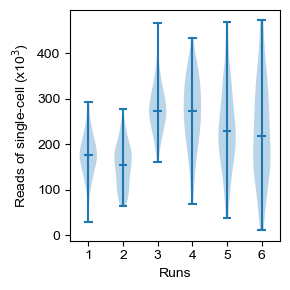

In [5]:
print('Cells', 'Median', 'Mean', sep='\t')
for vs in data1:
    print(len(vs), round(np.median(vs), 2), round(np.mean(vs), 2), sep='\t')
plt.figure(figsize=(3, 3))
plt.violinplot(data1, showmedians=True)
plt.xticks([1, 2, 3, 4, 5, 6])
plt.ylabel('Reads of single-cell (x10$^3$)')
plt.xlabel("Runs")
plt.tight_layout()
plt.show()
plt.close()

Cells	Median	Mean
83	175.98	175.75
85	153.66	154.1
58	273.28	278.2
50	274.25	269.32
84	229.14	235.87
78	218.33	226.84


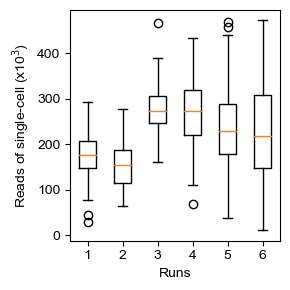

In [6]:
print('Cells', 'Median', 'Mean', sep='\t')
for vs in data1:
    print(len(vs), round(np.median(vs), 2), round(np.mean(vs), 2), sep='\t')
plt.figure(figsize=(3, 3))
plt.boxplot(data1)
plt.xticks([1, 2, 3, 4, 5, 6])
plt.ylabel('Reads of single-cell (x10$^3$)')
plt.xlabel("Runs")
plt.tight_layout()
plt.show()
plt.close()

Cells	Median	Mean
438	207.61	216.42


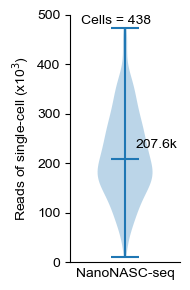

In [13]:
print('Cells', 'Median', 'Mean', sep='\t')
vs = data2
print(len(vs), round(np.median(vs), 2), round(np.mean(vs), 2), sep='\t')

plt.figure(figsize=(2, 3))
plt.violinplot(data2, showmedians=True)
plt.xlim(0.5, 1.5)
plt.ylim(0, 500)
plt.xticks([])
plt.text(0.6, 480, "Cells = %d" % len(vs))
plt.text(1.1, 230, "%.1fk" % np.median(vs))
plt.xlabel("NanoNASC-seq")
plt.ylabel('Reads of single-cell (x10$^3$)')
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/read_number_of_single_cell.pdf")
plt.show()
plt.close()

Cells	Median	Mean
438	207.61	216.42


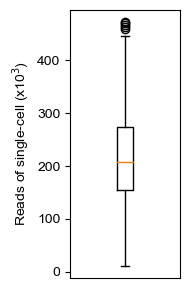

In [27]:
print('Cells', 'Median', 'Mean', sep='\t')
vs = data2
print(len(vs), round(np.median(vs), 2), round(np.mean(vs), 2), sep='\t')

plt.figure(figsize=(2, 3))
plt.boxplot(data2)
plt.xticks([])
plt.ylabel('Reads of single-cell (x10$^3$)')
plt.tight_layout()
plt.show()
plt.close()